In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 8],
    [9, 9],
    [10, 10]
])

In [5]:
def calc_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

In [7]:
groups = [list(range(len(X)))]

In [9]:
while len(groups) != 2:

    current = max(groups, key=len)
    groups.remove(current)

    point_distances = []

    for point in current:
        other_points = [
            calc_distance(X[point], X[j])
            for j in current
            if point != j
        ]
        point_distances.append((point, np.mean(other_points)))

    selected = max(point_distances, key=lambda item: item[1])[0]

    group_a = [selected]
    group_b = [point for point in current if point != selected]

    for point in group_b.copy():

        distance_a = calc_distance(X[point], X[selected])

        mean_point = np.mean(X[group_b], axis=0)
        distance_b = calc_distance(X[point], mean_point)

        if distance_a > distance_b:
            group_b.remove(point)
            group_a.append(point)

    groups.extend([group_a, group_b])

In [11]:
for number, group in enumerate(groups, start=1):
    print("Cluster", number)
    print(X[group])
    print()

Cluster 1
[[ 1  2]
 [ 8  8]
 [ 9  9]
 [10 10]]

Cluster 2
[[2 3]
 [3 4]]



In [13]:
labels = np.zeros(len(X), dtype=int)

for cluster_number, group in enumerate(groups):
    for index in group:
        labels[index] = cluster_number

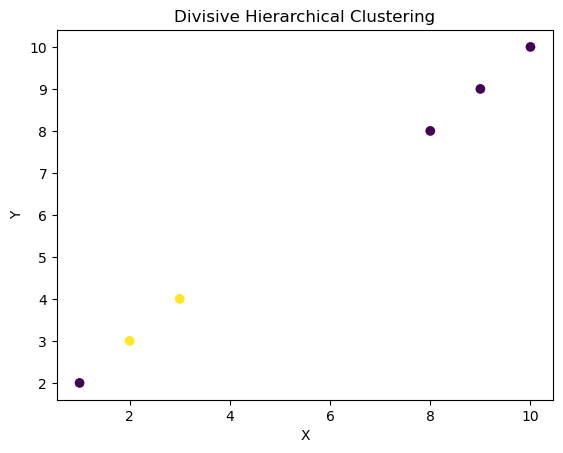

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=labels)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Divisive Hierarchical Clustering")

plt.show()